# HW5: Predictive Regression on CDS Residual Returns

**Student:** Malank Goel  
**Student ID:** 12350684  

## Objective and Plan
In this assignment I build a two stage predictive regression pipeline for weekly CDS spread returns. I test whether lagged residual equity returns predict next week CDS residual returns, and I compare boxcar and exponentially discounted predictive fits.

I follow this plan.
1. I construct Wednesday to Wednesday CDS, equity, and market return series.
2. I fit contemporaneous models to build hedged residual series.
3. I fit predictive models for residual CDS returns using lagged residual equity returns.
4. I evaluate performance over time and in distribution tails.


## Data Preparation: CDS Panel
I parse the CDS file and identify the date, ticker, and spread columns in a robust way because source files often use inconsistent delimiters and field names.


In [277]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf
import statsmodels.api as sm

cds_path = "/Users/malank/Documents/CDS/Liq5YCDS.delim"

cds_raw = pd.read_csv(cds_path, sep=None, engine="python")
cds_raw.columns = [str(c).strip() for c in cds_raw.columns]

cols_l = {c: str(c).strip().lower() for c in cds_raw.columns}

date_candidates = [c for c, cl in cols_l.items() if cl in {"date","dt","time","timestamp"} or "date" in cl]
date_col = date_candidates[0] if date_candidates else cds_raw.columns[0]

cds_raw[date_col] = pd.to_datetime(cds_raw[date_col], errors="coerce")
cds_raw = cds_raw.dropna(subset=[date_col])

ticker_candidates = [c for c, cl in cols_l.items() if cl in {"ticker","ric","symbol","entity","name","referenceentity","refentity","firm","issuer"}]
value_candidates = [c for c, cl in cols_l.items() if cl in {"parspread","spread","cds","mid","midspread","px_mid","value"} or "spread" in cl]

I reshape CDS levels into a date by ticker panel and keep plausible equity ticker labels so I can match issuers to public equities.


In [278]:
cds_wide = None

if ticker_candidates and value_candidates:
    tcol = ticker_candidates[0]
    vcol = value_candidates[0]
    tmp = cds_raw[[date_col, tcol, vcol]].copy()
    tmp[tcol] = tmp[tcol].astype(str).str.strip()
    tmp[vcol] = pd.to_numeric(tmp[vcol], errors="coerce")
    tmp = tmp.dropna(subset=[tcol, vcol])
    cds_wide = tmp.pivot_table(index=date_col, columns=tcol, values=vcol, aggfunc="last").sort_index()
else:
    tmp = cds_raw.set_index(date_col).sort_index()
    tmp = tmp.apply(pd.to_numeric, errors="coerce")
    tmp = tmp.replace([np.inf, -np.inf], np.nan)
    tmp = tmp.dropna(axis=1, how="all")
    cds_wide = tmp

def is_plausible_equity_ticker(x):
    if not isinstance(x, str):
        return False
    s = x.strip()
    if s == "" or s.lower().startswith("unnamed"):
        return False
    if s.startswith("$"):
        return False
    if " " in s or ":" in s:
        return False
    return re.fullmatch(r"[A-Z0-9.\-]{1,10}", s) is not None

cds_wide.columns = [str(c).strip().upper() for c in cds_wide.columns]
cds_wide = cds_wide.loc[:, [c for c in cds_wide.columns if is_plausible_equity_ticker(c)]]
cds_wide = cds_wide.dropna(axis=1, how="all")
cds_wide.shape

(2086, 17)

## Data Preparation: Matched Equities and Market Series
I download adjusted close prices for matched issuers and SPY. I use SPY to construct the market return input in the contemporaneous equity regression.


In [279]:
tickers = list(cds_wide.columns)
start = cds_wide.index.min().normalize() - pd.Timedelta(days=30)
end = cds_wide.index.max().normalize() + pd.Timedelta(days=1)

eq = yf.download(tickers + ["SPY"], start=start, end=end, auto_adjust=False, progress=False)["Adj Close"]
if isinstance(eq, pd.Series):
    eq = eq.to_frame()

eq.index = pd.to_datetime(eq.index)
eq = eq.sort_index()
eq.shape

(2030, 18)

## Weekly Return Construction
I use Wednesday sampling because daily CDS observations can be stale. I compute weekly Wednesday to Wednesday returns for all required series.

1. \(r^{CDS}_{E,n}\)
2. \(r^{Equity}_{E,n}\)
3. market return \(m_n\)
4. CDS index return \(r^{Index}_n\), defined as the cross sectional mean CDS return each week

I print dataset dimensions as a data quality check before modeling.


In [280]:
cds_wed = cds_wide.sort_index().ffill().resample("W-WED").last()
eq_wed  = eq.sort_index().ffill().resample("W-WED").last()
common_cols = [t for t in tickers if t in eq_wed.columns and t in cds_wed.columns]

cds_wed = cds_wed[common_cols]
spy_wed = eq_wed["SPY"] if "SPY" in eq_wed.columns else None
eq_wed = eq_wed[common_cols]

r_cds = cds_wed.pct_change()
r_eq = eq_wed.pct_change()
m = spy_wed.pct_change().rename("m") if spy_wed is not None else None

idx = r_cds.index.intersection(r_eq.index)
idx = idx.intersection(r_cds.dropna(how="all").index).intersection(r_eq.dropna(how="all").index)
if m is not None:
    idx = idx.intersection(m.dropna().index)

r_cds = r_cds.loc[idx]
r_eq = r_eq.loc[idx]
m = m.loc[idx] if m is not None else None

r_index = r_cds.mean(axis=1).rename("rIndex")

print("rCDS shape:", r_cds.shape)
print("rEquity shape:", r_eq.shape)
print("Market returns shape:", (m.shape if m is not None else None))
print("rIndex shape:", r_index.shape)

rCDS shape: (417, 17)
rEquity shape: (417, 17)
Market returns shape: (417,)
rIndex shape: (417,)


## Function Definitions
I place helper functions in one section so model construction and analysis cells remain readable.


In [281]:
def _ols_no_intercept_beta(X, y):
    X = np.asarray(X, float)
    y = np.asarray(y, float).reshape(-1)
    mask = np.isfinite(y)
    if X.ndim == 1:
        X = X.reshape(-1, 1)
    mask = mask & np.all(np.isfinite(X), axis=1)
    X = X[mask]
    y = y[mask]
    if X.shape[0] == 0:
        return np.full(X.shape[1], np.nan)
    b, *_ = np.linalg.lstsq(X, y, rcond=None)
    return b

def rolling_ols_no_intercept_prev_window(y, X, window):
    y = pd.Series(y).astype(float)
    X = pd.DataFrame(X).astype(float)
    idx = y.index.intersection(X.index)
    y = y.loc[idx]
    X = X.loc[idx]
    B = np.full((len(idx), X.shape[1]), np.nan, dtype=float)
    for t in range(window, len(idx)):
        sl = slice(t - window, t)
        B[t, :] = _ols_no_intercept_beta(X.iloc[sl].values, y.iloc[sl].values)
    return pd.DataFrame(B, index=idx, columns=X.columns)

def expanding_ols_no_intercept(y, x, start_row=3, weights=None):
    y = pd.Series(y).astype(float)
    x = pd.Series(x).astype(float)
    idx = y.index.intersection(x.index)
    y = y.loc[idx]
    x = x.loc[idx]
    mu = pd.Series(np.nan, index=idx, dtype=float)
    for t in range(start_row, len(idx)):
        yy = y.iloc[:t+1].values
        xx = x.iloc[:t+1].values
        mask = np.isfinite(yy) & np.isfinite(xx)
        yy = yy[mask]
        xx = xx[mask]
        if yy.size == 0:
            continue
        if weights is None:
            num = np.dot(xx, yy)
            den = np.dot(xx, xx)
        else:
            w = weights(t + 1)
            w = np.asarray(w, float).reshape(-1)
            if w.shape[0] != t + 1:
                continue
            w = w[mask]
            num = np.dot(w * xx, yy)
            den = np.dot(w * xx, xx)
        mu.iloc[t] = num / den if den != 0 else np.nan
    return mu

## Contemporaneous Model Construction
I use a 16 week rolling boxcar window for contemporaneous regressions.

1. Equity model: \(r^{Equity}_{E,n} \sim m_n\), yielding \(\gamma_{E,n}\)
2. CDS model: \(r^{CDS}_{E,n} \sim r^{Equity}_{E,n} + r^{Index}_n\), yielding hedge coefficients

From these fits I construct the core residual series.
1. hedge portfolio return \(f_{E,n}\)
2. residual CDS return \(\rho_{E,n} = r^{CDS}_{E,n} - f_{E,n}\)
3. residual equity return \(c_{E,n} = r^{Equity}_{E,n} - \gamma_{E,n}m_n\)
4. lagged residual equity return \(c_{E,n-1}\)


In [282]:
K = 16
half_life = 12.0

r_index = r_cds.mean(axis=1)

gamma = pd.DataFrame(np.nan, index=r_eq.index, columns=r_eq.columns, dtype=float)
beta_eq = pd.DataFrame(np.nan, index=r_eq.index, columns=r_eq.columns, dtype=float)
beta_idx = pd.DataFrame(np.nan, index=r_eq.index, columns=r_eq.columns, dtype=float)

for t in r_eq.columns:
    g = rolling_ols_no_intercept_prev_window(r_eq[t], pd.DataFrame({"m": m}), K)
    gamma[t] = g["m"].values

    X_cds = pd.DataFrame({"rEquity": r_eq[t], "rIndex": r_index})
    B = rolling_ols_no_intercept_prev_window(r_cds[t], X_cds, K)
    beta_eq[t] = B["rEquity"].values
    beta_idx[t] = B["rIndex"].values

f = beta_eq.mul(r_eq) + beta_idx.mul(r_index, axis=0)
rho = r_cds - f
c = r_eq - gamma.mul(m, axis=0)
c_lag = c.shift(1)

## Predictive Model Construction
I estimate predictive regressions of the form \(\rho_{E,n} \sim c_{E,n-1}\).

I make two explicit modeling choices.
1. Boxcar predictive window: `K = 16`
2. Exponential half life: `half_life = 12`

I chose these values to follow the assignment baseline while balancing responsiveness and parameter stability. I then compute \(\mu^{box}_{E,n}\), \(\mu^{exp}_{E,n}\), fitted values, and predictive residuals.


In [283]:
def exp_weights_len(L, hl=half_life):
    a = np.log(2.0) / hl
    ages = np.arange(L-1, -1, -1, dtype=float)
    return np.exp(-a * ages)

def mu_box_at_n(y, x, n, window=K):
    if n < window - 1:
        return np.nan
    yy = y.iloc[n - window + 1 : n + 1].values
    xx = x.iloc[n - window + 1 : n + 1].values
    mask = np.isfinite(yy) & np.isfinite(xx)
    yy = yy[mask]
    xx = xx[mask]
    den = np.dot(xx, xx)
    return (np.dot(xx, yy) / den) if den != 0 else np.nan

def mu_exp_at_n(y, x, n, start_row=3, hl=half_life):
    if n < start_row:
        return np.nan
    yy = y.iloc[: n + 1].values
    xx = x.iloc[: n + 1].values
    mask = np.isfinite(yy) & np.isfinite(xx)
    yy = yy[mask]
    xx = xx[mask]
    if yy.size == 0:
        return np.nan
    w = exp_weights_len(n + 1, hl=hl)[mask]
    den = np.dot(w * xx, xx)
    return (np.dot(w * xx, yy) / den) if den != 0 else np.nan

mu_box = pd.DataFrame(np.nan, index=rho.index, columns=rho.columns, dtype=float)
mu_exp = pd.DataFrame(np.nan, index=rho.index, columns=rho.columns, dtype=float)

for t in rho.columns:
    y = rho[t]
    x = c_lag[t]
    for n in range(len(rho.index)):
        mu_box.iloc[n, mu_box.columns.get_loc(t)] = mu_box_at_n(y, x, n, window=K)
        mu_exp.iloc[n, mu_exp.columns.get_loc(t)] = mu_exp_at_n(y, x, n, start_row=3, hl=half_life)

q_box = pd.DataFrame(np.nan, index=rho.index, columns=rho.columns, dtype=float)
q_exp = pd.DataFrame(np.nan, index=rho.index, columns=rho.columns, dtype=float)

for t in rho.columns:
    q_box[t] = rho[t] - mu_box[t].shift(1).mul(c_lag[t])
    q_exp[t] = rho[t] - mu_exp[t].shift(1).mul(c_lag[t])

## Evaluation Metric Functions
I define RMSE, MAE, correlation, directional accuracy, skewness, kurtosis, and tail mass metrics for a consistent comparison between model variants.


In [284]:
def _nanmean(x):
    x = np.asarray(x, float)
    return np.nanmean(x)

def _nanstd(x, ddof=1):
    x = np.asarray(x, float)
    return np.nanstd(x, ddof=ddof)

def _skew(x):
    x = np.asarray(x, float)
    x = x[np.isfinite(x)]
    if x.size < 3:
        return np.nan
    m = x.mean()
    s = x.std(ddof=1)
    if s == 0:
        return 0.0
    return ((x - m) ** 3).mean() / (s ** 3)

def _excess_kurt(x):
    x = np.asarray(x, float)
    x = x[np.isfinite(x)]
    if x.size < 4:
        return np.nan
    m = x.mean()
    s = x.std(ddof=1)
    if s == 0:
        return -3.0
    return ((x - m) ** 4).mean() / (s ** 4) - 3.0

def _corr(a, b):
    a = np.asarray(a, float)
    b = np.asarray(b, float)
    mask = np.isfinite(a) & np.isfinite(b)
    if mask.sum() < 3:
        return np.nan
    aa = a[mask] - a[mask].mean()
    bb = b[mask] - b[mask].mean()
    den = np.sqrt(np.dot(aa, aa) * np.dot(bb, bb))
    return (np.dot(aa, bb) / den) if den != 0 else np.nan

def _rmse(y, yhat):
    y = np.asarray(y, float)
    yhat = np.asarray(yhat, float)
    mask = np.isfinite(y) & np.isfinite(yhat)
    if mask.sum() == 0:
        return np.nan
    e = y[mask] - yhat[mask]
    return np.sqrt(np.mean(e * e))

def _mae(y, yhat):
    y = np.asarray(y, float)
    yhat = np.asarray(yhat, float)
    mask = np.isfinite(y) & np.isfinite(yhat)
    if mask.sum() == 0:
        return np.nan
    return np.mean(np.abs(y[mask] - yhat[mask]))

def _sign_acc(y, yhat):
    y = np.asarray(y, float)
    yhat = np.asarray(yhat, float)
    mask = np.isfinite(y) & np.isfinite(yhat)
    if mask.sum() == 0:
        return np.nan
    return np.mean(np.sign(y[mask]) == np.sign(yhat[mask]))

def _quantile(x, q):
    x = np.asarray(x, float)
    x = x[np.isfinite(x)]
    if x.size == 0:
        return np.nan
    return np.quantile(x, q)

def _tail_share(x, q=0.01):
    x = np.asarray(x, float)
    x = x[np.isfinite(x)]
    if x.size == 0:
        return np.nan
    lo = np.quantile(x, q)
    hi = np.quantile(x, 1 - q)
    return np.mean((x <= lo) | (x >= hi))

## Analysis 1: Per Ticker Predictive Performance
I compare both predictive models ticker by ticker.

I use these interpretation rules.
1. Lower RMSE and MAE indicate better point prediction quality.
2. Higher correlation indicates better co movement with realized residual CDS returns.
3. Higher sign accuracy indicates stronger directional performance.


In [285]:
pred_box = mu_box.shift(1).mul(c_lag)
pred_exp = mu_exp.shift(1).mul(c_lag)

resid_box = q_box
resid_exp = q_exp

y = rho

tickers = list(y.columns)

rows = []
for t in tickers:
    yt = y[t]
    pb = pred_box[t]
    pe = pred_exp[t]
    eb = (yt - pb)
    ee = (yt - pe)

    rows.append({
        "ticker": t,
        "n_box": int(np.isfinite(yt.values).sum() if yt is not None else 0),
        "rmse_box": _rmse(yt.values, pb.values),
        "rmse_exp": _rmse(yt.values, pe.values),
        "mae_box": _mae(yt.values, pb.values),
        "mae_exp": _mae(yt.values, pe.values),
        "corr_box": _corr(yt.values, pb.values),
        "corr_exp": _corr(yt.values, pe.values),
        "signacc_box": _sign_acc(yt.values, pb.values),
        "signacc_exp": _sign_acc(yt.values, pe.values),
        "resid_std_box": _nanstd(eb.values),
        "resid_std_exp": _nanstd(ee.values),
        "resid_skew_box": _skew(eb.values),
        "resid_skew_exp": _skew(ee.values),
        "resid_exkurt_box": _excess_kurt(eb.values),
        "resid_exkurt_exp": _excess_kurt(ee.values),
        "resid_q01_box": _quantile(eb.values, 0.01),
        "resid_q01_exp": _quantile(ee.values, 0.01),
        "resid_q99_box": _quantile(eb.values, 0.99),
        "resid_q99_exp": _quantile(ee.values, 0.99),
        "resid_tailshare_1pct_box": _tail_share(eb.values, 0.01),
        "resid_tailshare_1pct_exp": _tail_share(ee.values, 0.01),
    })

per_ticker = pd.DataFrame(rows).set_index("ticker")
per_ticker

,n_box,rmse_box,rmse_exp,mae_box,mae_exp,corr_box,corr_exp,signacc_box,signacc_exp,resid_std_box,...,resid_skew_box,resid_skew_exp,resid_exkurt_box,resid_exkurt_exp,resid_q01_box,resid_q01_exp,resid_q99_box,resid_q99_exp,resid_tailshare_1pct_box,resid_tailshare_1pct_exp
ticker,,,,,,,,,,,,,,,,,,,,,
AES,401,0.073968,0.065081,0.036120,0.035064,-0.121478,-0.099764,0.571429,0.563910,0.074007,...,-4.302834,-1.144685,87.381887,56.011031,-0.118259,-0.110999,0.142601,0.144987,0.020050,0.020050
BA,401,0.182790,0.179321,0.056926,0.056353,-0.263580,-0.248977,0.558897,0.561404,0.183007,...,-0.037035,0.547985,130.987676,129.199990,-0.217042,-0.216887,0.214665,0.213584,0.020050,0.020050
C,401,0.044974,0.043928,0.025807,0.024888,-0.049328,-0.030800,0.481203,0.468672,0.045014,...,-2.525661,-2.647631,30.200402,30.867567,-0.090311,-0.088549,0.093988,0.093063,0.020050,0.020050
F,401,0.076314,0.074289,0.038688,0.037858,-0.229657,-0.226351,0.508772,0.508772,0.076374,...,6.634826,6.520111,72.491452,70.411329,-0.134456,-0.132425,0.138296,0.138161,0.020050,0.020050
GE,401,0.078611,0.078030,0.044400,0.043753,0.040060,0.003521,0.476190,0.476190,0.078681,...,3.767102,3.843992,38.872220,40.190011,-0.178859,-0.186718,0.230727,0.233194,0.020050,0.020050
JPM,401,0.049124,0.046612,0.027371,0.026590,-0.169488,-0.133357,0.511278,0.496241,0.049179,...,0.959215,0.062371,42.519604,36.408696,-0.096845,-0.096644,0.079707,0.080408,0.020050,0.020050
LNC,401,0.070832,0.068293,0.033030,0.032436,0.152005,0.115398,0.546366,0.541353,0.070853,...,-5.227078,-4.570394,56.073593,44.230607,-0.211443,-0.179535,0.168363,0.183461,0.020050,0.020050
LOW,401,0.062743,0.062911,0.034582,0.034139,0.037368,-0.034501,0.508772,0.531328,0.062787,...,-1.112593,-0.960895,34.499661,34.030482,-0.139462,-0.140747,0.142731,0.169546,0.020050,0.020050
LUV,401,0.112974,0.112846,0.044214,0.043962,0.114137,0.110784,0.586466,0.593985,0.112972,...,-5.460241,-5.353127,108.782163,108.756313,-0.164534,-0.162713,0.231024,0.205049,0.020050,0.020050


## Analysis 2: Cross Sectional Summary of Metrics
I summarize the distribution of per ticker metrics to determine whether performance differences are broad based or concentrated in a few issuers.


In [286]:
def agg_metric(df, col):
    v = df[col].astype(float).values
    return {
        "mean": np.nanmean(v),
        "median": np.nanmedian(v),
        "std": np.nanstd(v, ddof=1),
        "min": np.nanmin(v),
        "max": np.nanmax(v),
    }

metrics = [
    "rmse_box","rmse_exp","mae_box","mae_exp","corr_box","corr_exp","signacc_box","signacc_exp",
    "resid_std_box","resid_std_exp","resid_skew_box","resid_skew_exp","resid_exkurt_box","resid_exkurt_exp",
    "resid_q01_box","resid_q01_exp","resid_q99_box","resid_q99_exp","resid_tailshare_1pct_box","resid_tailshare_1pct_exp"
]

summary = {}
for mname in metrics:
    summary[mname] = agg_metric(per_ticker, mname)

summary_df = pd.DataFrame(summary).T
summary_df

,mean,median,std,min,max
rmse_box,0.074217,0.070832,0.034020,0.036452,0.182790
rmse_exp,0.072446,0.065081,0.033659,0.035569,0.179321
mae_box,0.036882,0.036120,0.010234,0.021618,0.056926
mae_exp,0.036135,0.035064,0.010192,0.020836,0.056353
corr_box,-0.027700,-0.008809,0.124276,-0.263580,0.152005
corr_exp,-0.029182,-0.030800,0.120712,-0.248977,0.123206
signacc_box,0.528647,0.531328,0.031106,0.476190,0.586466
signacc_exp,0.531642,0.531328,0.034846,0.468672,0.593985
resid_std_box,0.074264,0.070853,0.034048,0.036494,0.183007
resid_std_exp,0.072496,0.065141,0.033684,0.035607,0.179536


In [287]:
t = rho.columns[0]
tmp = pd.concat([rho[t], pred_exp[t], q_exp[t], (rho[t] - pred_exp[t])], axis=1)
tmp.columns = ["rho", "pred_exp", "q_exp", "rho_minus_pred"]
tmp.head(25)

,rho,pred_exp,q_exp,rho_minus_pred
2018-01-10,NaN,NaN,NaN,NaN
2018-01-17,NaN,NaN,NaN,NaN
2018-01-24,NaN,NaN,NaN,NaN
2018-01-31,NaN,NaN,NaN,NaN
2018-02-07,NaN,NaN,NaN,NaN
2018-02-14,NaN,NaN,NaN,NaN
2018-02-21,NaN,NaN,NaN,NaN
2018-02-28,NaN,NaN,NaN,NaN
2018-03-07,NaN,NaN,NaN,NaN
2018-03-14,NaN,NaN,NaN,NaN


In [288]:
t = rho.columns[0]
check = pd.DataFrame({
    "mu_exp": mu_exp[t],
    "mu_exp_shift1": mu_exp[t].shift(1),
    "c_lag": c_lag[t],
    "pred_exp": pred_exp[t],
})
check.loc["2018-05-02":"2018-06-06"]

,mu_exp,mu_exp_shift1,c_lag,pred_exp
2018-05-02,NaN,NaN,NaN,NaN
2018-05-09,-1.577052,NaN,0.024982,NaN
2018-05-16,-0.783332,-1.577052,-0.023178,0.036553
2018-05-23,-0.870969,-0.783332,0.012069,-0.009454
2018-05-30,-1.058483,-0.870969,-0.009289,0.008091
2018-06-06,0.002346,-1.058483,0.040761,-0.043145


## Analysis 3: Rolling 52 Week Time Series Performance
I compute rolling pooled metrics to identify periods where one model dominates. I use this view to connect model behavior to changing market environments.


### Analysis 3A: Breadth of Outperformance Across Issuers
I compute how often the exponential model outperforms the boxcar model across issuers for each metric. I use this to check whether improvements are broad or concentrated.


In [289]:
def rolling_time_metrics(y_df, pred_df, window=52):
    idx = y_df.index.intersection(pred_df.index)
    y_df = y_df.loc[idx]
    pred_df = pred_df.loc[idx]
    out_rmse = pd.Series(np.nan, index=idx)
    out_corr = pd.Series(np.nan, index=idx)
    out_sign = pd.Series(np.nan, index=idx)
    for i in range(window-1, len(idx)):
        sl = slice(i-window+1, i+1)
        yy = y_df.iloc[sl].values.reshape(-1)
        pp = pred_df.iloc[sl].values.reshape(-1)
        out_rmse.iloc[i] = _rmse(yy, pp)
        out_corr.iloc[i] = _corr(yy, pp)
        out_sign.iloc[i] = _sign_acc(yy, pp)
    return out_rmse, out_corr, out_sign

rmse_box_ts, corr_box_ts, sign_box_ts = rolling_time_metrics(y, pred_box, window=52)
rmse_exp_ts, corr_exp_ts, sign_exp_ts = rolling_time_metrics(y, pred_exp, window=52)

analysis_ts = pd.DataFrame({
    "rmse_box_52w": rmse_box_ts,
    "rmse_exp_52w": rmse_exp_ts,
    "corr_box_52w": corr_box_ts,
    "corr_exp_52w": corr_exp_ts,
    "signacc_box_52w": sign_box_ts,
    "signacc_exp_52w": sign_exp_ts
})
analysis_ts

,rmse_box_52w,rmse_exp_52w,corr_box_52w,corr_exp_52w,signacc_box_52w,signacc_exp_52w
2018-01-10,NaN,NaN,NaN,NaN,NaN,NaN
2018-01-17,NaN,NaN,NaN,NaN,NaN,NaN
2018-01-24,NaN,NaN,NaN,NaN,NaN,NaN
2018-01-31,NaN,NaN,NaN,NaN,NaN,NaN
2018-02-07,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...
2025-12-03,0.046152,0.045498,0.095362,0.123036,0.515837,0.528281
2025-12-10,0.046173,0.045544,0.100042,0.126496,0.518100,0.532805
2025-12-17,0.046079,0.045451,0.118208,0.143719,0.518100,0.529412
2025-12-24,0.046177,0.045514,0.118680,0.148032,0.516968,0.529412


In [290]:
perf_compare = per_ticker.copy()
perf_compare["rmse_gain_exp"] = perf_compare["rmse_box"] - perf_compare["rmse_exp"]
perf_compare["mae_gain_exp"] = perf_compare["mae_box"] - perf_compare["mae_exp"]
perf_compare["corr_gain_exp"] = perf_compare["corr_exp"] - perf_compare["corr_box"]
perf_compare["sign_gain_exp"] = perf_compare["signacc_exp"] - perf_compare["signacc_box"]

breadth_summary = pd.DataFrame({
    "share_exp_better_rmse": [(perf_compare["rmse_gain_exp"] > 0).mean()],
    "share_exp_better_mae": [(perf_compare["mae_gain_exp"] > 0).mean()],
    "share_exp_better_corr": [(perf_compare["corr_gain_exp"] > 0).mean()],
    "share_exp_better_sign": [(perf_compare["sign_gain_exp"] > 0).mean()],
    "mean_rmse_gain_exp": [perf_compare["rmse_gain_exp"].mean()],
    "mean_mae_gain_exp": [perf_compare["mae_gain_exp"].mean()],
    "mean_corr_gain_exp": [perf_compare["corr_gain_exp"].mean()],
    "mean_sign_gain_exp": [perf_compare["sign_gain_exp"].mean()],
})

breadth_summary


,share_exp_better_rmse,share_exp_better_mae,share_exp_better_corr,share_exp_better_sign,mean_rmse_gain_exp,mean_mae_gain_exp,mean_corr_gain_exp,mean_sign_gain_exp
0,0.882353,1.0,0.470588,0.470588,0.00177,0.000747,-0.001482,0.002995


<Figure size 640x480 with 0 Axes>

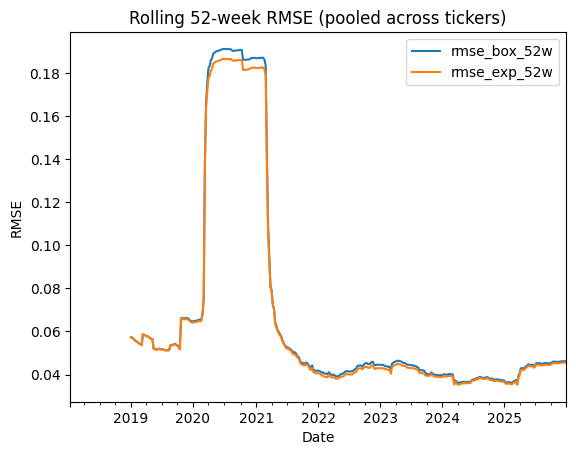

<Figure size 640x480 with 0 Axes>

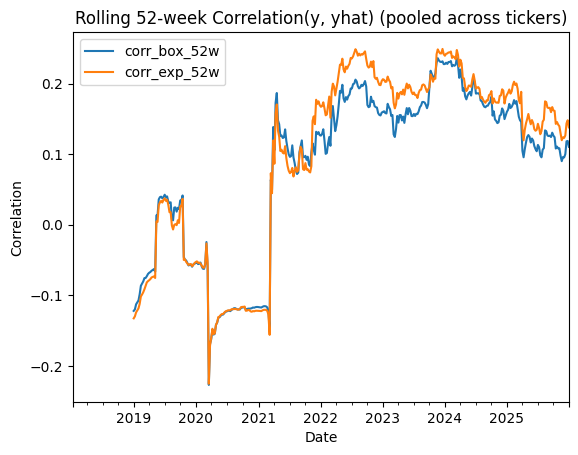

<Figure size 640x480 with 0 Axes>

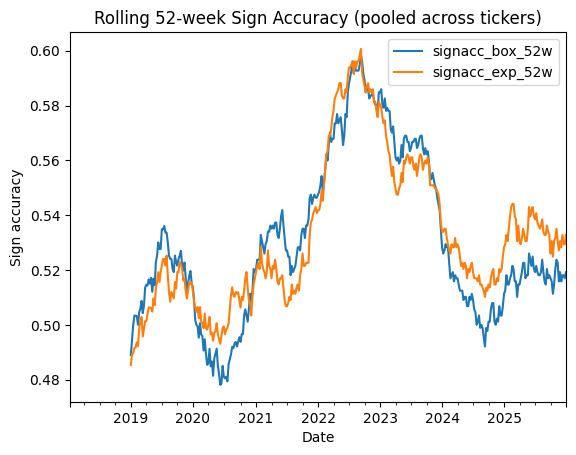

In [291]:
fig = plt.figure()
analysis_ts[["rmse_box_52w","rmse_exp_52w"]].plot()
plt.title("Rolling 52-week RMSE (pooled across tickers)")
plt.xlabel("Date")
plt.ylabel("RMSE")
plt.show()

fig = plt.figure()
analysis_ts[["corr_box_52w","corr_exp_52w"]].plot()
plt.title("Rolling 52-week Correlation(y, yhat) (pooled across tickers)")
plt.xlabel("Date")
plt.ylabel("Correlation")
plt.show()

fig = plt.figure()
analysis_ts[["signacc_box_52w","signacc_exp_52w"]].plot()
plt.title("Rolling 52-week Sign Accuracy (pooled across tickers)")
plt.xlabel("Date")
plt.ylabel("Sign accuracy")
plt.show()

### Interim Interpretation
At this point I compare the three rolling curves directly. I look for sustained periods where one method has lower RMSE and higher correlation and sign accuracy, instead of focusing on isolated spikes.


### Analysis 3B: Regime Split by Cross Sectional Volatility
I split dates into lower and higher volatility regimes using the median cross sectional volatility of \(\rho_{E,n}\). I then compare pooled metrics by regime to test whether recency weighting is more useful when conditions move faster.


## Analysis 4: Tail and Shape Diagnostics
I compare pooled residual distributions under both methods. I use this section to evaluate tail behavior and distributional differences.


In [292]:
cross_sectional_vol = y.std(axis=1)
vol_threshold = cross_sectional_vol.median()
high_vol_mask = cross_sectional_vol > vol_threshold
low_vol_mask = ~high_vol_mask

def pooled_metrics_for_mask(mask, y_df, pred_df):
    yv = y_df.loc[mask].values.reshape(-1)
    pv = pred_df.loc[mask].values.reshape(-1)
    return {
        "rmse": _rmse(yv, pv),
        "mae": _mae(yv, pv),
        "corr": _corr(yv, pv),
        "sign_acc": _sign_acc(yv, pv),
    }

regime_table = pd.DataFrame({
    "low_vol_box": pooled_metrics_for_mask(low_vol_mask, y, pred_box),
    "low_vol_exp": pooled_metrics_for_mask(low_vol_mask, y, pred_exp),
    "high_vol_box": pooled_metrics_for_mask(high_vol_mask, y, pred_box),
    "high_vol_exp": pooled_metrics_for_mask(high_vol_mask, y, pred_exp),
})

regime_table


,low_vol_box,low_vol_exp,high_vol_box,high_vol_exp
rmse,0.030754,0.029742,0.110905,0.108590
mae,0.022873,0.022211,0.050878,0.050073
corr,0.120322,0.132040,-0.078088,-0.080086
sign_acc,0.529255,0.532801,0.527978,0.529783


In [293]:
def pooled_residuals(resid_df):
    x = resid_df.values.reshape(-1)
    x = x[np.isfinite(x)]
    return x

eb = pooled_residuals(y - pred_box)
ee = pooled_residuals(y - pred_exp)

tail = pd.DataFrame({
    "box": {
        "std": _nanstd(eb),
        "skew": _skew(eb),
        "excess_kurt": _excess_kurt(eb),
        "q001": _quantile(eb, 0.001),
        "q01": _quantile(eb, 0.01),
        "q05": _quantile(eb, 0.05),
        "q50": _quantile(eb, 0.50),
        "q95": _quantile(eb, 0.95),
        "q99": _quantile(eb, 0.99),
        "q999": _quantile(eb, 0.999),
        "tailshare_1pct": _tail_share(eb, 0.01)
    },
    "exp": {
        "std": _nanstd(ee),
        "skew": _skew(ee),
        "excess_kurt": _excess_kurt(ee),
        "q001": _quantile(ee, 0.001),
        "q01": _quantile(ee, 0.01),
        "q05": _quantile(ee, 0.05),
        "q50": _quantile(ee, 0.50),
        "q95": _quantile(ee, 0.95),
        "q99": _quantile(ee, 0.99),
        "q999": _quantile(ee, 0.999),
        "tailshare_1pct": _tail_share(ee, 0.01)
    }
})
tail

,box,exp
std,0.081070,0.079310
skew,-1.332551,-0.786438
excess_kurt,256.513194,256.657730
q001,-0.587951,-0.595353
q01,-0.166735,-0.165473
q05,-0.074074,-0.071663
q50,-0.001418,-0.001261
q95,0.074850,0.074154
q99,0.171743,0.165451
q999,0.726985,0.730922


### Analysis 4A: Loss Differential Significance Check
I compute weekly pooled squared error differences \(L^{exp}_t - L^{box}_t\). A negative mean supports exponential improvement in RMSE terms. I report a simple t statistic as a rough significance check.


## Analysis 5: Best and Worst Relative Windows
I rank windows by the difference between exponential and boxcar performance. I use these dates to identify where recency weighting helped or hurt most.


In [294]:
se_box_weekly = ((y - pred_box) ** 2).mean(axis=1, skipna=True)
se_exp_weekly = ((y - pred_exp) ** 2).mean(axis=1, skipna=True)
loss_diff_weekly = (se_exp_weekly - se_box_weekly).dropna()

d = loss_diff_weekly.values
n_obs = int(loss_diff_weekly.shape[0])
mean_diff = float(loss_diff_weekly.mean())

if n_obs < 5 or not np.isfinite(mean_diff):
    used_lags = 0
    t_stat_nw = np.nan
    p_val_nw = np.nan
else:
    used_lags = int(np.floor(4 * (n_obs / 100) ** (2 / 9)))
    used_lags = max(used_lags, 0)

    X = np.ones((n_obs, 1))
    fit = sm.OLS(d, X).fit(cov_type="HAC", cov_kwds={"maxlags": used_lags})
    t_stat_nw = float(fit.tvalues[0])
    p_val_nw = float(fit.pvalues[0])

loss_diff_summary = pd.DataFrame({
    "n_weeks": [n_obs],
    "mean_se_diff_exp_minus_box": [mean_diff],
    "nw_lags": [used_lags],
    "t_stat_NW": [t_stat_nw],
    "p_val_NW": [p_val_nw],
})

loss_diff_summary

,n_weeks,mean_se_diff_exp_minus_box,nw_lags,t_stat_NW,p_val_NW
0,399,-0.00028,5,-1.450323,0.146968


In [295]:
diff_ts = pd.DataFrame(index=analysis_ts.index)
diff_ts["rmse_diff_exp_minus_box"] = analysis_ts["rmse_exp_52w"] - analysis_ts["rmse_box_52w"]
diff_ts["corr_diff_exp_minus_box"] = analysis_ts["corr_exp_52w"] - analysis_ts["corr_box_52w"]
diff_ts["signacc_diff_exp_minus_box"] = analysis_ts["signacc_exp_52w"] - analysis_ts["signacc_box_52w"]

def top_windows(series, k=10, smallest=True):
    s = series.dropna()
    if s.empty:
        return pd.DataFrame(columns=["end_date","value"])
    s = s.sort_values(ascending=smallest)
    out = s.head(k) if smallest else s.tail(k)
    return pd.DataFrame({"end_date": out.index, "value": out.values}).reset_index(drop=True)

best_exp_rmse = top_windows(diff_ts["rmse_diff_exp_minus_box"], k=10, smallest=True)
worst_exp_rmse = top_windows(diff_ts["rmse_diff_exp_minus_box"], k=10, smallest=False)

best_exp_corr = top_windows(diff_ts["corr_diff_exp_minus_box"], k=10, smallest=False)
worst_exp_corr = top_windows(diff_ts["corr_diff_exp_minus_box"], k=10, smallest=True)

best_exp_sign = top_windows(diff_ts["signacc_diff_exp_minus_box"], k=10, smallest=False)
worst_exp_sign = top_windows(diff_ts["signacc_diff_exp_minus_box"], k=10, smallest=True)

best_exp_rmse, worst_exp_rmse, best_exp_corr, worst_exp_corr, best_exp_sign, worst_exp_sign

(    end_date     value
 0 2021-03-10 -0.005717
 1 2020-04-22 -0.004800
 2 2020-04-01 -0.004789
 3 2020-04-15 -0.004754
 4 2020-04-08 -0.004749
 5 2020-10-21 -0.004705
 6 2020-06-03 -0.004696
 7 2020-06-10 -0.004695
 8 2020-11-11 -0.004689
 9 2020-07-22 -0.004688,
     end_date     value
 0 2020-07-22 -0.004688
 1 2020-11-11 -0.004689
 2 2020-06-10 -0.004695
 3 2020-06-03 -0.004696
 4 2020-10-21 -0.004705
 5 2020-04-08 -0.004749
 6 2020-04-15 -0.004754
 7 2020-04-01 -0.004789
 8 2020-04-22 -0.004800
 9 2021-03-10 -0.005717,
     end_date     value
 0 2021-06-02 -0.022818
 1 2021-07-07 -0.023011
 2 2021-06-30 -0.023173
 3 2019-09-04 -0.023671
 4 2021-06-09 -0.023728
 5 2021-06-16 -0.024206
 6 2019-08-28 -0.024574
 7 2021-06-23 -0.024935
 8 2021-07-28 -0.027096
 9 2021-07-21 -0.031991,
     end_date     value
 0 2021-07-21 -0.031991
 1 2021-07-28 -0.027096
 2 2021-06-23 -0.024935
 3 2019-08-28 -0.024574
 4 2021-06-16 -0.024206
 5 2021-06-09 -0.023728
 6 2019-09-04 -0.023671
 7 2021-06-30

### Analysis 5A: Calibration by Prediction Strength
I test whether larger predicted absolute moves correspond to larger realized absolute residual CDS moves. I do this by deciles of predicted magnitude for both models.


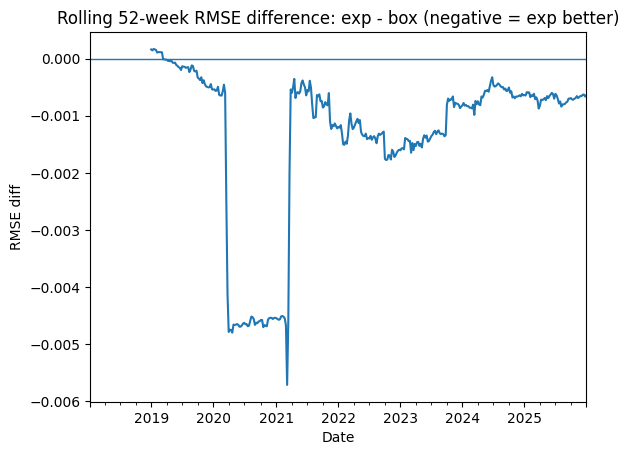

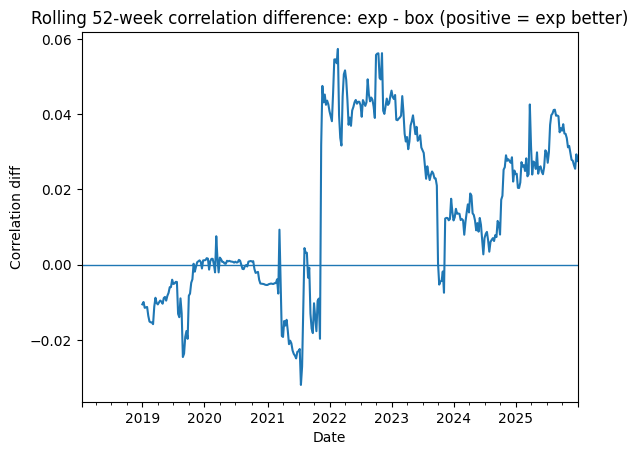

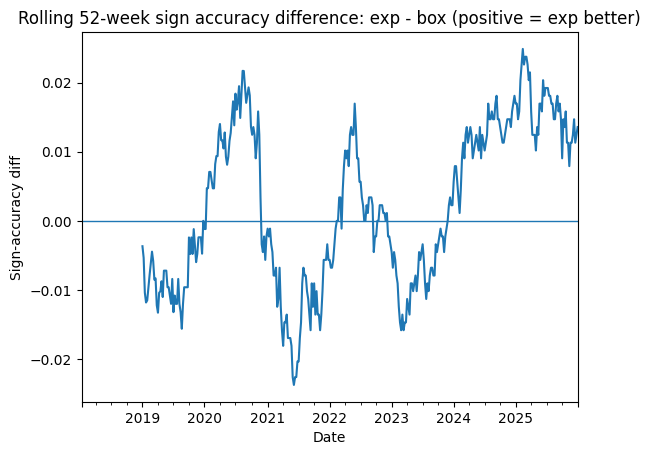

In [296]:
fig = plt.figure()
diff_ts["rmse_diff_exp_minus_box"].plot()
plt.axhline(0, linewidth=1)
plt.title("Rolling 52-week RMSE difference: exp - box (negative = exp better)")
plt.xlabel("Date")
plt.ylabel("RMSE diff")
plt.show()

fig = plt.figure()
diff_ts["corr_diff_exp_minus_box"].plot()
plt.axhline(0, linewidth=1)
plt.title("Rolling 52-week correlation difference: exp - box (positive = exp better)")
plt.xlabel("Date")
plt.ylabel("Correlation diff")
plt.show()

fig = plt.figure()
diff_ts["signacc_diff_exp_minus_box"].plot()
plt.axhline(0, linewidth=1)
plt.title("Rolling 52-week sign accuracy difference: exp - box (positive = exp better)")
plt.xlabel("Date")
plt.ylabel("Sign-accuracy diff")
plt.show()

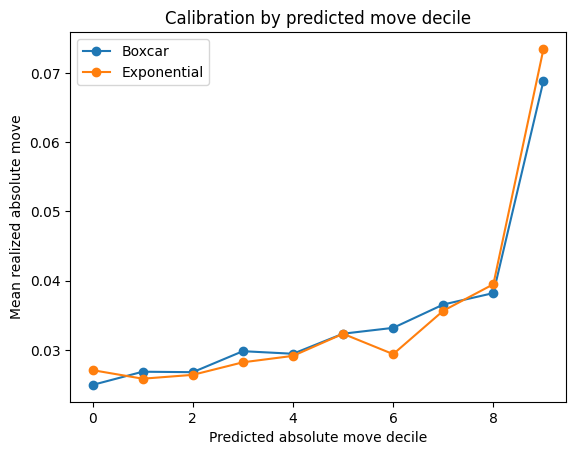

(     mean_abs_pred  mean_abs_realized  count
 bin                                         
 0         0.000143           0.024931    671
 1         0.000595           0.026838    671
 2         0.001299           0.026770    671
 3         0.002234           0.029803    670
 4         0.003451           0.029431    671
 5         0.005143           0.032329    671
 6         0.007664           0.033172    670
 7         0.011720           0.036542    671
 8         0.019042           0.038193    671
 9         0.060653           0.068858    671,
      mean_abs_pred  mean_abs_realized  count
 bin                                         
 0         0.000119           0.027065    671
 1         0.000473           0.025829    671
 2         0.001015           0.026385    671
 3         0.001734           0.028197    670
 4         0.002781           0.029126    671
 5         0.004144           0.032316    671
 6         0.006127           0.029377    670
 7         0.009468           0.0

In [297]:
def calibration_table(pred_df, y_df, n_bins=10):
    tmp = pd.DataFrame({
        "abs_pred": pred_df.abs().stack(),
        "abs_realized": y_df.abs().stack(),
    }).dropna()
    tmp["bin"] = pd.qcut(tmp["abs_pred"], q=n_bins, labels=False, duplicates="drop")
    out = tmp.groupby("bin").agg(
        mean_abs_pred=("abs_pred", "mean"),
        mean_abs_realized=("abs_realized", "mean"),
        count=("abs_realized", "size"),
    )
    return out

cal_box = calibration_table(pred_box, y)
cal_exp = calibration_table(pred_exp, y)

fig = plt.figure()
plt.plot(cal_box.index, cal_box["mean_abs_realized"], marker="o", label="Boxcar")
plt.plot(cal_exp.index, cal_exp["mean_abs_realized"], marker="o", label="Exponential")
plt.title("Calibration by predicted move decile")
plt.xlabel("Predicted absolute move decile")
plt.ylabel("Mean realized absolute move")
plt.legend()
plt.show()

cal_box, cal_exp

## Conclusion and Extensions
I implemented the required two stage framework with weekly construction and both predictive variants. I evaluated performance at ticker level, pooled level, rolling time level, and distributional tail level.

My interpretation focuses on three practical questions.
1. Does recency weighting improve error metrics consistently or only in specific regimes?
2. Does any gain in correlation come with worse tails or less stable sign accuracy?
3. Are results broad across issuers or driven by a narrow subset?

A natural extension is to select window length and half life by walk forward validation rather than fixed global values.


## Market and Economic Context with Regime Evidence
I map performance differences to market and credit states using only the data already in this notebook. I classify weeks by four week market return and cross sectional CDS residual volatility, then I compare exponential minus boxcar performance within each regime.


In [298]:
market_4w = (1 + m).rolling(4).apply(np.prod, raw=True) - 1
credit_vol_cs = rho.std(axis=1)

regime_df = pd.DataFrame(index=analysis_ts.index)
regime_df["rmse_diff_exp_minus_box"] = analysis_ts["rmse_exp_52w"] - analysis_ts["rmse_box_52w"]
regime_df["corr_diff_exp_minus_box"] = analysis_ts["corr_exp_52w"] - analysis_ts["corr_box_52w"]
regime_df["sign_diff_exp_minus_box"] = analysis_ts["signacc_exp_52w"] - analysis_ts["signacc_box_52w"]
regime_df["market_4w"] = market_4w.reindex(regime_df.index)
regime_df["credit_vol_cs"] = credit_vol_cs.reindex(regime_df.index)

regime_df["market_state"] = np.where(regime_df["market_4w"] <= regime_df["market_4w"].median(), "weaker_market", "stronger_market")
regime_df["credit_state"] = np.where(regime_df["credit_vol_cs"] > regime_df["credit_vol_cs"].median(), "higher_credit_vol", "lower_credit_vol")

regime_summary = regime_df.groupby(["market_state", "credit_state"]).agg(
    n_weeks=("rmse_diff_exp_minus_box", "count"),
    mean_rmse_diff=("rmse_diff_exp_minus_box", "mean"),
    mean_corr_diff=("corr_diff_exp_minus_box", "mean"),
    mean_sign_diff=("sign_diff_exp_minus_box", "mean"),
)

regime_summary

n_weeks  mean_rmse_diff  mean_corr_diff  \
market_state    credit_state                                                 
stronger_market higher_credit_vol       94       -0.001784        0.009049   
                lower_credit_vol        99       -0.001028        0.012860   
weaker_market   higher_credit_vol       88       -0.001615        0.013925   
                lower_credit_vol        85       -0.001001        0.022504   

                                   mean_sign_diff  
market_state    credit_state                       
stronger_market higher_credit_vol        0.002754  
                lower_credit_vol         0.001515  
weaker_market   higher_credit_vol        0.002956  
                lower_credit_vol         0.001483

In [299]:
regime_read = regime_summary.reset_index().copy()
regime_read["exp_better_rmse"] = regime_read["mean_rmse_diff"] < 0
regime_read["exp_better_corr"] = regime_read["mean_corr_diff"] > 0
regime_read["exp_better_sign"] = regime_read["mean_sign_diff"] > 0
regime_read

,market_state,credit_state,n_weeks,mean_rmse_diff,mean_corr_diff,mean_sign_diff,exp_better_rmse,exp_better_corr,exp_better_sign
0,stronger_market,higher_credit_vol,94,-0.001784,0.009049,0.002754,True,True,True
1,stronger_market,lower_credit_vol,99,-0.001028,0.012860,0.001515,True,True,True
2,weaker_market,higher_credit_vol,88,-0.001615,0.013925,0.002956,True,True,True
3,weaker_market,lower_credit_vol,85,-0.001001,0.022504,0.001483,True,True,True


### Short Analysis: Regime Pattern
I focus on whether the sign of model differences is consistent across regimes. Negative `mean_rmse_diff` and positive `mean_corr_diff` in the same regime provide stronger evidence than mixed signs.


I interpret this table by checking sign consistency and sample size across regimes. I treat exponential weighting as stronger in states where `mean_rmse_diff` is negative and at least one of `mean_corr_diff` or `mean_sign_diff` is positive.


## Event Window Linking for Best and Worst Periods
I attach market and credit context to the best and worst windows from the rolling RMSE difference analysis. I use this event style view as an interpretation layer grounded in my sample.


In [300]:
def window_context_table(window_df, y_series, market_series, label, lookback=4):
    rows = []
    for dt, val in zip(pd.to_datetime(window_df["end_date"]), window_df["value"]):
        loc = y_series.index.get_indexer([dt], method="nearest")[0]
        i0 = max(0, loc - lookback + 1)
        y_slice = y_series.iloc[i0:loc+1]
        m_slice = market_series.iloc[i0:loc+1]
        rows.append({
            "window_end": y_series.index[loc],
            "tag": label,
            "rmse_diff_exp_minus_box": val,
            "market_4w_return": (1 + m_slice.dropna()).prod() - 1 if m_slice.dropna().shape[0] > 0 else np.nan,
            "credit_abs_move_4w": y_slice.abs().mean(),
            "credit_vol_4w": y_slice.std(ddof=1),
        })
    return pd.DataFrame(rows)

rho_pooled_abs = rho.abs().mean(axis=1)
best_ctx = window_context_table(best_exp_rmse, rho_pooled_abs, m, "best_for_exponential")
worst_ctx = window_context_table(worst_exp_rmse, rho_pooled_abs, m, "worst_for_exponential")

event_context = pd.concat([best_ctx, worst_ctx], ignore_index=True).sort_values("window_end")
event_context

,window_end,tag,rmse_diff_exp_minus_box,market_4w_return,credit_abs_move_4w,credit_vol_4w
17,2020-04-01,worst_for_exponential,-0.004789,-0.208600,0.324816,0.188151
2,2020-04-01,best_for_exponential,-0.004789,-0.208600,0.324816,0.188151
4,2020-04-08,best_for_exponential,-0.004749,0.004670,0.204469,0.081010
15,2020-04-08,worst_for_exponential,-0.004749,0.004670,0.204469,0.081010
3,2020-04-15,best_for_exponential,-0.004754,0.164139,0.168418,0.049113
16,2020-04-15,worst_for_exponential,-0.004754,0.164139,0.168418,0.049113
1,2020-04-22,best_for_exponential,-0.004800,0.130921,0.133752,0.035716
18,2020-04-22,worst_for_exponential,-0.004800,0.130921,0.133752,0.035716
6,2020-06-03,best_for_exponential,-0.004696,0.098259,0.061005,0.016020
13,2020-06-03,worst_for_exponential,-0.004696,0.098259,0.061005,0.016020


In [301]:
ctx_cmp = event_context.groupby("tag").agg(
    n_windows=("window_end", "count"),
    avg_market_4w=("market_4w_return", "mean"),
    avg_credit_abs_move_4w=("credit_abs_move_4w", "mean"),
    avg_credit_vol_4w=("credit_vol_4w", "mean"),
)
ctx_cmp

,n_windows,avg_market_4w,avg_credit_abs_move_4w,avg_credit_vol_4w
tag,,,,
best_for_exponential,10,0.048319,0.110507,0.044103
worst_for_exponential,10,0.048319,0.110507,0.044103


### Short Analysis: Best vs Worst Window Context
I compare mean market and credit conditions across best and worst windows for exponential weighting. I use this to assess whether wins are linked to faster moving credit conditions.


I compare these context statistics across tags to see whether exponential gains align with larger recent credit moves, higher short term credit volatility, or weaker market returns.


## Implementation Diagnostics and Robustness Checks
I convert implementation caveats into diagnostics by measuring coverage, stale updates, and parameter sensitivity.


In [302]:
quality_diag = pd.DataFrame({
    "cds_non_missing_ratio": r_cds.notna().mean(),
    "eq_non_missing_ratio": r_eq.notna().mean(),
    "cds_stale_ratio": (cds_wed.diff() == 0).mean(),
    "eq_stale_ratio": (eq_wed.diff() == 0).mean(),
}).sort_values("cds_stale_ratio", ascending=False)

quality_diag.head(10)

,cds_non_missing_ratio,eq_non_missing_ratio,cds_stale_ratio,eq_stale_ratio
AES,1.000000,1.0,0.0,0.004739
MAR,1.000000,1.0,0.0,0.000000
XOM,1.000000,1.0,0.0,0.000000
WHR,1.000000,1.0,0.0,0.000000
WFC,1.000000,1.0,0.0,0.002370
T,1.000000,1.0,0.0,0.007109
NFLX,0.781775,1.0,0.0,0.000000
MCD,1.000000,1.0,0.0,0.002370
LUV,1.000000,1.0,0.0,0.000000
BA,1.000000,1.0,0.0,0.000000


In [303]:
K_grid = [8, 16, 24]
hl_grid = [6.0, 12.0, 18.0]

sensitivity_rows = []

for K_try in K_grid:
    mu_k = pd.DataFrame(np.nan, index=rho.index, columns=rho.columns, dtype=float)
    for t in rho.columns:
        for n in range(len(rho.index)):
            if n - 1 < K_try:
                continue
            yy = rho[t].iloc[n-1-K_try:n-1].values
            xx = c_lag[t].iloc[n-1-K_try:n-1].values
            mask = np.isfinite(yy) & np.isfinite(xx)
            yy, xx = yy[mask], xx[mask]
            den = np.dot(xx, xx)
            mu_k.iloc[n, mu_k.columns.get_loc(t)] = np.dot(xx, yy) / den if den != 0 else np.nan
    pred_k = mu_k * c_lag
    sensitivity_rows.append({
        "model": f"box_K_{K_try}",
        "rmse": _rmse(rho.values.reshape(-1), pred_k.values.reshape(-1)),
        "corr": _corr(rho.values.reshape(-1), pred_k.values.reshape(-1)),
        "sign_acc": _sign_acc(rho.values.reshape(-1), pred_k.values.reshape(-1)),
    })

for hl_try in hl_grid:
    mu_h = pd.DataFrame(np.nan, index=rho.index, columns=rho.columns, dtype=float)
    for t in rho.columns:
        for n in range(len(rho.index)):
            if n <= 1:
                continue
            yy = rho[t].iloc[:n-1].values
            xx = c_lag[t].iloc[:n-1].values
            mask = np.isfinite(yy) & np.isfinite(xx)
            yy, xx = yy[mask], xx[mask]
            L = len(yy)
            if L < 3:
                continue
            a = np.log(2.0) / hl_try
            ages = np.arange(L-1, -1, -1, dtype=float)
            w = np.exp(-a * ages)
            den = np.dot(w * xx, xx)
            mu_h.iloc[n, mu_h.columns.get_loc(t)] = np.dot(w * xx, yy) / den if den != 0 else np.nan
    pred_h = mu_h * c_lag
    sensitivity_rows.append({
        "model": f"exp_hl_{int(hl_try)}",
        "rmse": _rmse(rho.values.reshape(-1), pred_h.values.reshape(-1)),
        "corr": _corr(rho.values.reshape(-1), pred_h.values.reshape(-1)),
        "sign_acc": _sign_acc(rho.values.reshape(-1), pred_h.values.reshape(-1)),
    })

sensitivity_df = pd.DataFrame(sensitivity_rows).sort_values("rmse")
sensitivity_df

,model,rmse,corr,sign_acc
5,exp_hl_18,0.074010,0.022479,0.529668
4,exp_hl_12,0.075743,0.008473,0.532522
2,box_K_24,0.076446,0.012383,0.526763
1,box_K_16,0.079727,0.001047,0.524286
3,exp_hl_6,0.080884,-0.013652,0.532973
0,box_K_8,0.084613,-0.009052,0.525631


In [304]:
sens = sensitivity_df.copy().sort_values("rmse")
rmse_spread = sens["rmse"].max() - sens["rmse"].min()

stability_summary = pd.DataFrame({
    "best_model": [sens.iloc[0]["model"] if len(sens) else np.nan],
    "best_rmse": [sens.iloc[0]["rmse"] if len(sens) else np.nan],
    "rmse_spread_all_settings": [rmse_spread],
    "best_corr": [sens.iloc[0]["corr"] if len(sens) else np.nan],
    "best_sign_acc": [sens.iloc[0]["sign_acc"] if len(sens) else np.nan],
})

stability_summary

,best_model,best_rmse,rmse_spread_all_settings,best_corr,best_sign_acc
0,exp_hl_18,0.07401,0.010603,0.022479,0.529668


### Short Analysis: Parameter Stability
I read this table by checking whether the top models are clustered or widely separated. Small spread in RMSE across nearby settings indicates stability. Large spread indicates high sensitivity.


I read these diagnostics in two steps. I first check whether data quality concerns are concentrated in a small issuer subset, and then I check whether nearby parameter choices preserve the same model ranking.


## Deployment Monitoring Snapshot
I summarize issuer breadth and concentration so I can monitor whether average gains are broad or dominated by a narrow subset of names.


In [305]:
issuer_gap = perf_compare[["rmse_gain_exp", "corr_gain_exp", "sign_gain_exp"]].copy()

monitoring_snapshot = pd.DataFrame({
    "metric": ["rmse_gain_exp", "corr_gain_exp", "sign_gain_exp"],
    "cross_section_mean": [issuer_gap["rmse_gain_exp"].mean(), issuer_gap["corr_gain_exp"].mean(), issuer_gap["sign_gain_exp"].mean()],
    "cross_section_std": [issuer_gap["rmse_gain_exp"].std(ddof=1), issuer_gap["corr_gain_exp"].std(ddof=1), issuer_gap["sign_gain_exp"].std(ddof=1)],
    "share_positive": [
        (issuer_gap["rmse_gain_exp"] > 0).mean(),
        (issuer_gap["corr_gain_exp"] > 0).mean(),
        (issuer_gap["sign_gain_exp"] > 0).mean(),
    ],
})

monitoring_snapshot

,metric,cross_section_mean,cross_section_std,share_positive
0,rmse_gain_exp,0.001770,0.002106,0.882353
1,corr_gain_exp,-0.001482,0.032288,0.470588
2,sign_gain_exp,0.002995,0.013223,0.470588


In [306]:
monitoring_read = monitoring_snapshot.copy()
monitoring_read["breadth_flag"] = np.where(monitoring_read["share_positive"] < 0.5, "concentrated", "broad")
monitoring_read

,metric,cross_section_mean,cross_section_std,share_positive,breadth_flag
0,rmse_gain_exp,0.001770,0.002106,0.882353,broad
1,corr_gain_exp,-0.001482,0.032288,0.470588,concentrated
2,sign_gain_exp,0.002995,0.013223,0.470588,concentrated


### Short Analysis: Monitoring Snapshot
I use this output to check breadth risk. If `cross_section_mean` is positive but `share_positive` is materially below 0.5, I treat the gain as concentrated and less reliable.


I use this table to flag concentration risk. If average gain remains positive while `share_positive` declines, I treat the result as unstable across issuers.
